Practical Project

Predicting Cancer Treatment Cost


Hospitals want to estimate how much a patient's treatment will cost based on patient information.

Target Variable - Treatment Cost

Features - Age, BMI, Number of Hospital Visits, Length of Stay,Severity Score

Step 2: Import Libraries

In [1]:
# Import pandas for working with tables (DataFrames)
import pandas as pd

# Import numpy for mathematical operations
import numpy as np

# Import matplotlib for creating charts
import matplotlib.pyplot as plt

# Import Linear Regression algorithm from Scikit-learn
from sklearn.linear_model import LinearRegression

# Import train_test_split to divide our data into training and testing sets
from sklearn.model_selection import train_test_split

# Import evaluation metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

Step 3: Load Dataset

In [3]:
# Load the CSV dataset into a pandas DataFrame
df = pd.read_csv("cancer_treatment_cost.csv")

Step 4: View Dataset

In [ ]:
# Display the first five rows of the dataset
df.head()

,Age,BMI,Hospital_Visits,Length_of_Stay,Severity_Score,Treatment_Cost
0,32,18.6,5,8,4,512024
1,31,32.9,9,3,10,745071
2,22,18.7,4,8,9,715513
3,21,30.3,12,18,7,970186
4,75,31.0,1,6,7,615098


Step 4: View Dataset

In [ ]:
# Display information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              300 non-null    int64  
 1   BMI              300 non-null    float64
 2   Hospital_Visits  300 non-null    int64  
 3   Length_of_Stay   300 non-null    int64  
 4   Severity_Score   300 non-null    int64  
 5   Treatment_Cost   300 non-null    int64  
dtypes: float64(1), int64(5)
memory usage: 14.2 KB


Step 6: Statistical Summary

In [ ]:
# Generate summary statistics for all numerical columns
df.describe()

,Age,BMI,Hospital_Visits,Length_of_Stay,Severity_Score,Treatment_Cost
count,300.000000,300.000000,300.000000,300.000000,300.000000,3.000000e+02
mean,53.610000,29.185333,6.593333,11.320000,5.446667,7.330448e+05
std,19.382557,6.586221,3.463323,5.824432,2.925008,1.760663e+05
min,18.000000,18.000000,1.000000,1.000000,1.000000,2.931970e+05
25%,37.000000,23.400000,3.750000,6.750000,3.000000,6.087202e+05
50%,55.500000,29.150000,7.000000,11.000000,5.000000,7.251310e+05
75%,71.000000,35.125000,10.000000,17.000000,8.000000,8.615125e+05
max,85.000000,39.900000,12.000000,20.000000,10.000000,1.193678e+06


Step 7: Check Missing Values

In [ ]:
# Count missing values in each column
df.isnull().sum()

,0
Age,0
BMI,0
Hospital_Visits,0
Length_of_Stay,0
Severity_Score,0
Treatment_Cost,0


Step 8: Select Features

Features are the inputs

In [ ]:
# Select the input features (independent variables)
X = df[['Age', 'BMI', 'Hospital_Visits', 'Length_of_Stay', 'Severity_Score']]

Step 9: Select Target Variable

In [ ]:
# Select the target variable (dependent variable)
y = df['Treatment_Cost']

Step 10: Split Dataset

In [ ]:
# Split the data into training and testing sets
# test_size=0.2 means 20% of the data is reserved for testing
# random_state=42 ensures the split is reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Step 11: Create the Model

In [ ]:
# Create an instance of the Linear Regression model
model = LinearRegression()

Step 12: Train the Model

In [ ]:
# Train the model using the training data
model.fit(X_train, y_train)

LinearRegression()

Step 13: Make Predictions

In [ ]:
# Use the trained model to predict treatment costs for the test data
predictions = model.predict(X_test)

Step 14: Compare Predictions

In [ ]:
# Create a new DataFrame to compare actual and predicted values
results = pd.DataFrame({
    'Actual Cost': y_test,
    'Predicted Cost': predictions
})

# Display the first ten comparisons
results.head(10)

,Actual Cost,Predicted Cost
203,820351,826275.127372
266,325205,323218.480361
152,812563,793391.657631
9,501454,470471.137087
233,586937,569296.714493
226,858936,889001.327738
196,886095,868626.352478
109,796447,776299.051987
5,405018,404755.423418
175,908268,918972.650965


Step 15: Evaluate the Model

Mean Absolute Error

In [ ]:
# Calculate the average absolute prediction error
mae = mean_absolute_error(y_test, predictions)

# Print the MAE value
print("Mean Absolute Error:", mae)

Mean Absolute Error: 15545.345428154014


Mean Squared Error

In [ ]:
# Calculate the average squared prediction error
mse = mean_squared_error(y_test, predictions)

# Print the MSE value
print("Mean Squared Error:", mse)

Mean Squared Error: 318047225.8114742


R² Score

In [ ]:
# Calculate the R² score to measure how well the model explains the data
r2 = r2_score(y_test, predictions)

# Print the R² score
print("R² Score:", r2)

R² Score: 0.9913220912083085


Step 16: Visualize Predictions

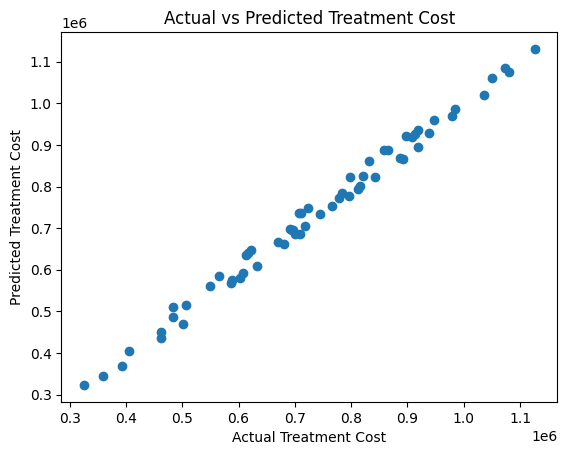

In [ ]:
# Create a scatter plot comparing actual and predicted values
plt.scatter(y_test, predictions)

# Label the x-axis
plt.xlabel("Actual Treatment Cost")

# Label the y-axis
plt.ylabel("Predicted Treatment Cost")

# Add a title to the chart
plt.title("Actual vs Predicted Treatment Cost")

# Display the plot
plt.show()

Step 17: Predict for a New Patient

This simulates a real hospital system where doctors enter patient details and receive an estimated treatment cost.

In [ ]:
# Create a DataFrame containing the details of a new patient
new_patient = pd.DataFrame({
    'Age': [45],
    'BMI': [28],
    'Hospital_Visits': [4],
    'Length_of_Stay': [7],
    'Severity_Score': [6]
})

# Predict the treatment cost for the new patient
predicted_cost = model.predict(new_patient)

# Print the predicted treatment cost
print("Predicted Treatment Cost:", predicted_cost[0])

Predicted Treatment Cost: 607598.9588428315


Understanding What the Model Learned

Every feature contributes differently.

Positive coefficient

↑ increases treatment cost.

Negative coefficient

↓ decreases treatment cost.

In [ ]:
# Display the coefficients (weights) assigned to each feature
print(model.coef_)

# Display the intercept (starting point) of the regression equation
print(model.intercept_)

[ 1257.42216607  2031.49361335 14678.98972958 22316.61271398
 40475.79905559]
36346.09794615407


Complete Machine Learning Workflow

Collect Data

      ↓
Load Dataset

      ↓
Explore Dataset

      ↓
Clean Dataset

      ↓
Select Features

      ↓
Split Dataset

      ↓
Train Model

      ↓
Predict

      ↓
Evaluate

      ↓
Deploy